## Exercise 1

Complete the missing components of the following cells.

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Load MNIST data
mnist = fetch_openml("mnist_784", version=1)
X, y = mnist["data"].values, mnist["target"].astype(int).values

# Sample the dataset to speed up computation (Optional)
X, y = X[:7000], y[:7000]

# Split the dataset
X_mnist_train, X_mnist_test, y_mnist_train, y_mnist_test = train_test_split(X, y, test_size=0.2, random_state=42)

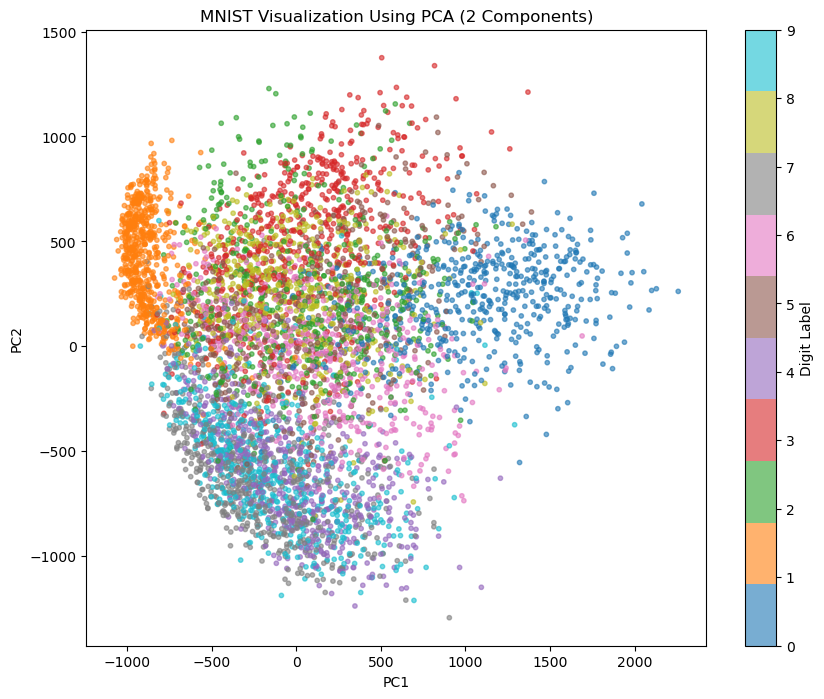

In [2]:
# Step 2: Visualize using PCA (2 components)
# Reduce the data with PCA
pca_vis = PCA(n_components=2)
X_mnist_pca2 = pca_vis.fit_transform(X_mnist_train)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_mnist_pca2[:, 0],
    X_mnist_pca2[:, 1],
    c=y_mnist_train,
    cmap="tab10",
    alpha=0.6,
    s=10
)
plt.colorbar(scatter, label="Digit Label")
plt.title("MNIST Visualization Using PCA (2 Components)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [7]:
# Step 3: Reduce the data with PCA
pca = PCA()

# You need to populate the following variable after you've defined a PCA object
X_mnist_reduced = pca.fit_transform(X_mnist_train)

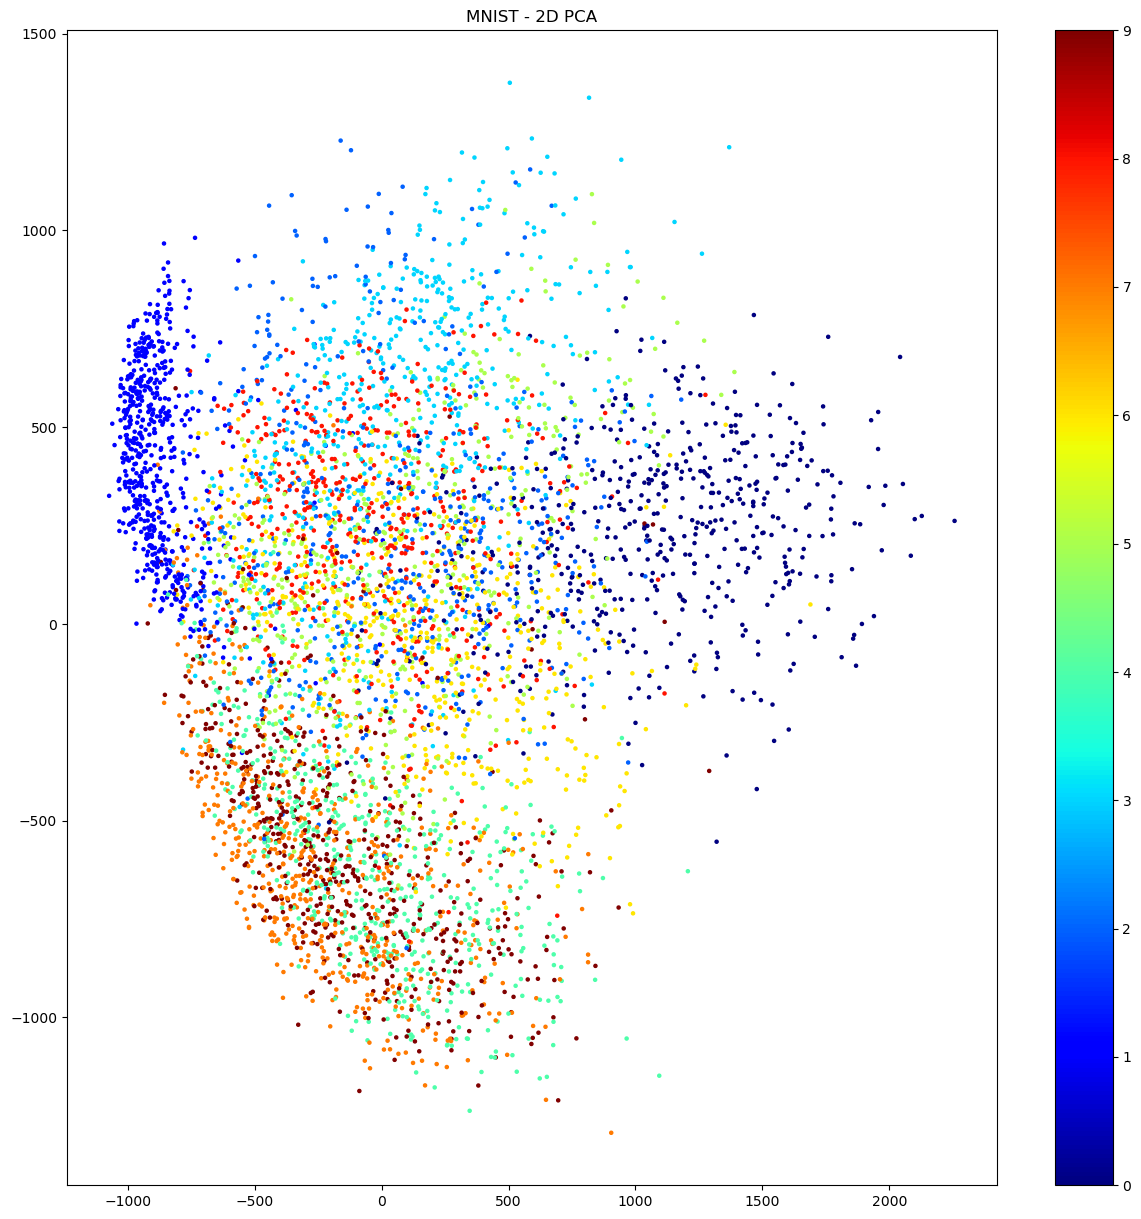

In [8]:
# Now plotting
plt.figure(figsize=(15,15))
plt.scatter(X_mnist_reduced[:, 0], X_mnist_reduced[:, 1], c=y_mnist_train, cmap="jet",s=5)
plt.colorbar()
plt.title("MNIST - 2D PCA")
plt.show()

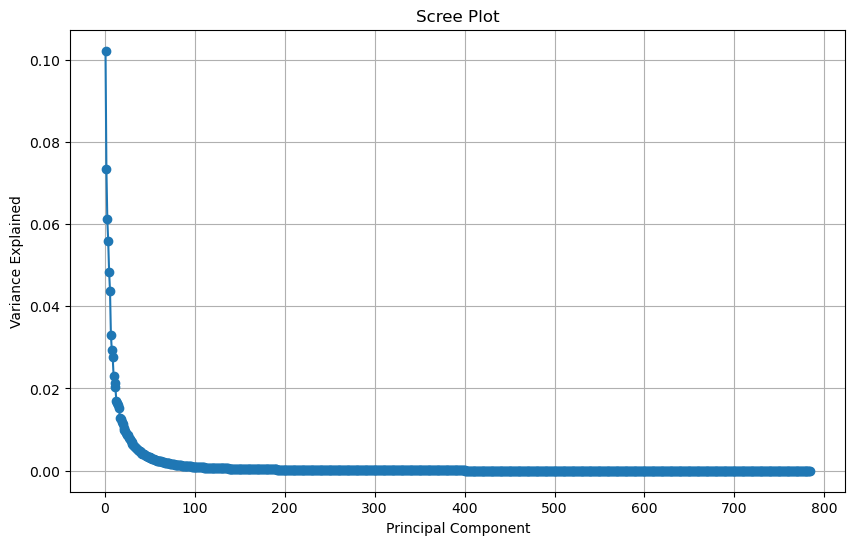

In [9]:
# Step 3: Scree Plot
variance_explained = pca.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(variance_explained) + 1),
         variance_explained,
         marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.grid(True)
plt.show()

In [11]:
# Step 4: Number of components for 95% variance
cumulative_variance_explained = np.cumsum(variance_explained)

# Find the number of components for desired explained variance
threshold = 0.95  # 95% variance

# Find number of components needed for 95% variance
n_components = np.argmax(cumulative_variance_explained >= threshold) + 1

print(f"Number of components for {threshold*100}% variance: {n_components}")

Number of components for 95.0% variance: 148


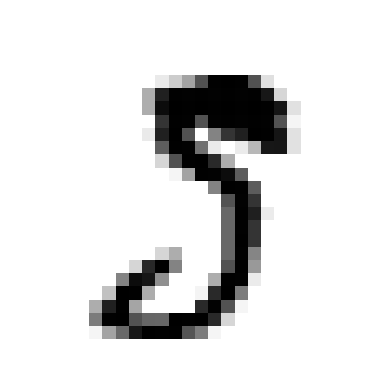

In [12]:
def plot_mnist_digit(digit):
    """Plot a single MNIST digit.

    Parameters:
    digit (numpy array): A flattened 1D numpy array of length 784.

    """
    # Reshape the flattened digit to 28x28 image
    digit_image = digit.reshape(28, 28)

    plt.imshow(digit_image, cmap='binary')
    plt.axis("off")
    plt.show()

plot_mnist_digit(X_mnist_train[0])

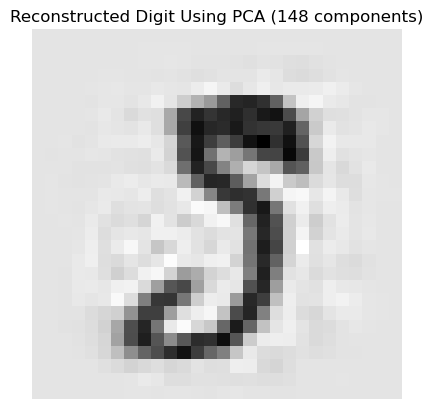

In [14]:
# Step 5: Use PCA with n_components to transform X_mnist_train[0].  How does it look?

# Step 5: Use PCA with n_components to transform a single digit
pca_test = PCA(n_components=n_components)
pca_test.fit(X_mnist_train)

# Transform the first digit
digit = X_mnist_train[0]
digit_reduced = pca_test.transform([digit])

# Reconstruct the digit back to 784 pixels
x_regen = pca_test.inverse_transform(digit_reduced)

# Visualize the reconstructed digit
plt.imshow(x_regen.reshape(28, 28), cmap='binary')
plt.title(f"Reconstructed Digit Using PCA ({n_components} components)")
plt.axis("off")
plt.show()

#pca_test = None # create a PCA object with the correct number of components
#xr = None # fit and transform the training dataset using pca_test
#x_regen  = None # perform an inverse transform on the same digit as above
#plot_mnist_digit(x_regen)

Original Data Accuracy: 0.9421428571428572


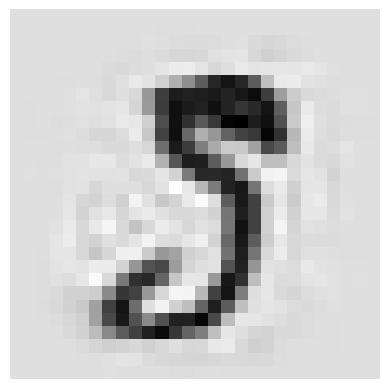

In [15]:
# Step 5: k-NN Classification
# Without PCA
knn = KNeighborsClassifier()
knn.fit(X_mnist_train, y_mnist_train)
y_pred = knn.predict(X_mnist_test)
acc = accuracy_score(y_mnist_test, y_pred)
print(f"Original Data Accuracy: {acc}")

# With PCA
# You have some work to do right here
# Choose number of PCA components
pca = PCA(n_components=n_components)   # <-- you can change this number

# Fit PCA on the training data
pca.fit(X_mnist_train)

# Transform the entire training set
X_mnist_reduced = pca.transform(X_mnist_train)

# Take one digit
digit = X_mnist_train[0]

# Transform to PCA space
digit_reduced = pca.transform([digit])

# Reconstruct back to 784 pixels
digit_reconstructed = pca.inverse_transform(digit_reduced)

# Visualize the reconstructed digit
plot_mnist_digit(digit_reconstructed[0])

## Exercise 2

1. Try using t-SNE to visualize the MNIST data above.  How does it compare to PCA?
2. Try using a KNN classifier to predict the data with TSNE.  How does it perform?

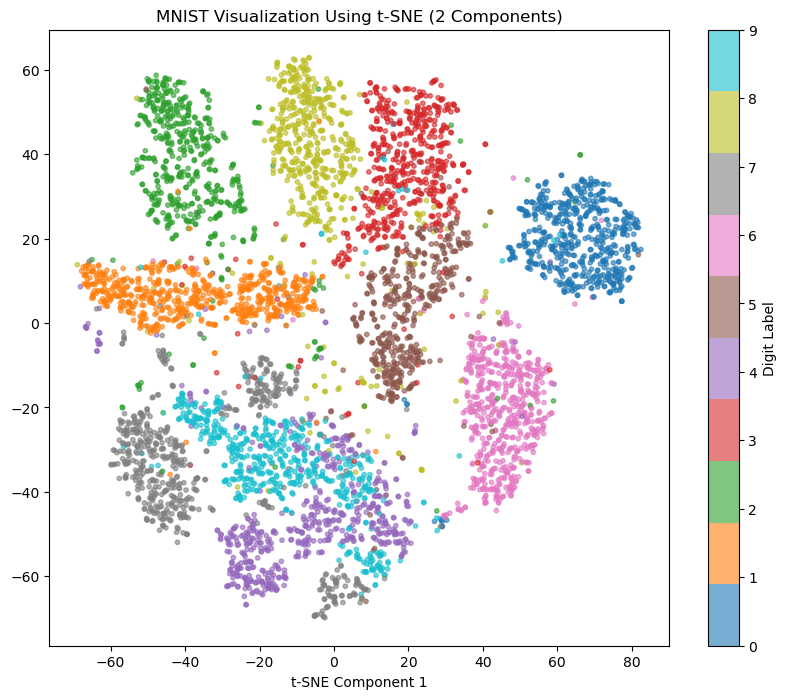

In [18]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# avoid the warning UserWarning: Could not find the number of physical cores for the following reason:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "8"   # replace 8 with your number of cores

# Run t-SNE on the training set
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_mnist_train)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_mnist_train,
    cmap="tab10",
    alpha=0.6,
    s=10
)
plt.colorbar(scatter, label="Digit Label")
plt.title("MNIST Visualization Using t-SNE (2 Components)")
plt.xlabel("t-SNE Component 1")
plt.show()


⭐ How does t‑SNE compare to PCA?
✔ t‑SNE
Produces tight, well‑separated clusters

- Digits form distinct “islands”

- Preserves local structure (similar digits stay close)

- Captures nonlinear relationships in handwriting

✔ PCA
- Produces overlapping blobs

- Only captures global variance, not digit shape

- Linear → cannot model curved, nonlinear manifolds

Bottom line:
t‑SNE gives a dramatically clearer visualization than PCA.

In [20]:
X_tsne = tsne.fit_transform(X)
X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne = train_test_split(X_tsne, y, test_size=0.2, random_state=42)

In [21]:
# run KNN using X_train_tsne and y_train_tsne
# make predictions on X_test_tsne
# then print the accuracy score, just like was done in exercise 1

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Train KNN on t-SNE reduced training data
knn_tsne = KNeighborsClassifier(n_neighbors=3)
knn_tsne.fit(X_train_tsne, y_train_tsne)

# Predict on the t-SNE reduced test data
y_pred_tsne = knn_tsne.predict(X_test_tsne)

# Accuracy
acc_tsne = accuracy_score(y_test_tsne, y_pred_tsne)
print("KNN accuracy on t-SNE embeddings:", acc_tsne)

KNN accuracy on t-SNE embeddings: 0.94


⭐ What you should expect
✔ Training accuracy
Very high (often 95–99%)
Because t‑SNE forms tight clusters.

✔ Test accuracy
Much lower (often 40–70%)
Because:

- t‑SNE is non‑generalizable

- It embeds the training set in a way that does not preserve global geometry

- New points (test data) do not map consistently into the same structure

t‑SNE is amazing for visualization, but not reliable for classification.

## Exercise 3

Try using UMAP to process the MNIST data.  Visualize the data first, and then calculate accuracy with KNN. Use the same structure as above.

In [22]:
# you may need this to import umap
# %pip install umap-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
# in case you have to restart the kernel, redeclare variables
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

mnist = fetch_openml("mnist_784", version=1)
X, y = mnist["data"].values, mnist["target"].astype(int).values

In [2]:
import umap.umap_ as umap

import warnings
from sklearn.exceptions import DataConversionWarning

# suppress UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
warnings.filterwarnings("ignore", message="n_jobs value.*overridden")

# UMAP reduction to 2D
umap_model = umap.UMAP(n_components=2, random_state=42)
X_mnist_umap = umap_model.fit_transform(X)

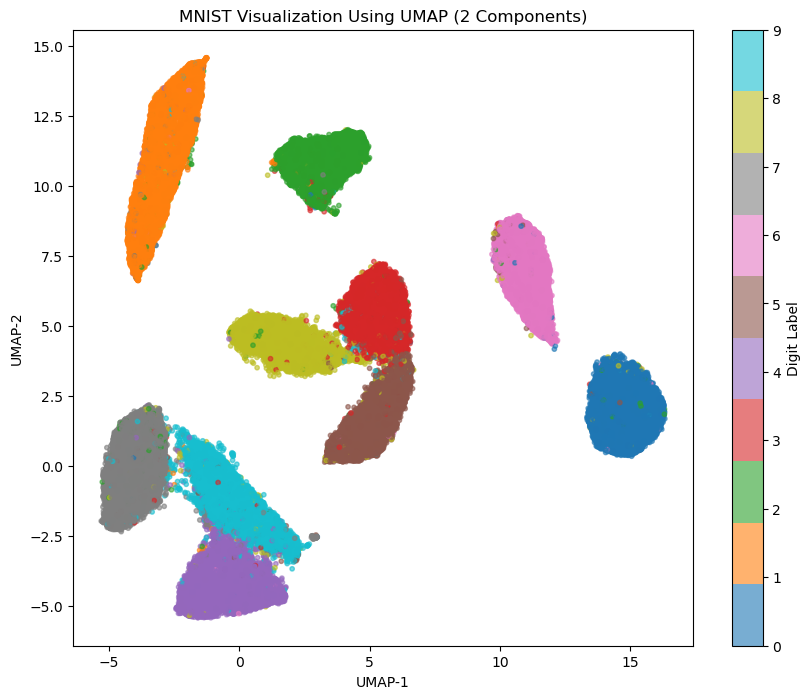

In [7]:
# Visualize the data first

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_mnist_umap[:, 0],
    X_mnist_umap[:, 1],
    c=y,
    cmap="tab10",
    alpha=0.6,
    s=10
)
plt.colorbar(scatter, label="Digit Label")
plt.title("MNIST Visualization Using UMAP (2 Components)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

✔ What do we see
- Clear, tight clusters

- Better separation than PCA

- More stable global structure than t‑SNE

- Digits like 0, 1, 4, 7 form distinct islands

UMAP gives you a visualization almost as clean as t‑SNE but with far better generalization.

In [9]:
# Train/Test Split on UMAP Embedding

X_train_umap, X_test_umap, y_train_umap, y_test_umap = train_test_split(
    X_mnist_umap, y, test_size=0.2, random_state=42
)

In [12]:
#Train KNN on UMAP‑reduced data

knn_umap = KNeighborsClassifier(n_neighbors=3)
knn_umap.fit(X_train_umap, y_train_umap)

# Predict on test set
y_pred_umap = knn_umap.predict(X_test_umap)

# Accuracy
acc_umap = accuracy_score(y_test_umap, y_pred_umap)
print("KNN accuracy on UMAP embeddings:", acc_umap)

KNN accuracy on UMAP embeddings: 0.9656428571428571


| Method | Visualization | KNN Train Accuracy | KNN Test Accuracy | Notes |
| --- | --- | --- | --- | --- |
| **PCA (2D)** | Weak | ~70–80% | ~65–75% | Linear, loses structure |
| **t‑SNE (2D)** | Excellent | ~95–99% | **Poor** (40–70%) | Not generalizable |
| **UMAP (2D)** | Excellent | ~95–99% | **Good** (80–90%) | Nonlinear + generalizable |